<a href="https://colab.research.google.com/github/JotaBlanco/TheValley/blob/main/Workshops/Non%20Supervised%20Models/Workshop_Modelos_No_Supervisados_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de clustering

## Objetivos:

Prácticar con el uso de clusters en un contexto real, desarrollando un conocimiento e intuición sólidas sobre:
- Clusterización con k-means
- Distribución de variables en los distintos clusters
- Cálculo de distancias en el espacio de características


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EJERCICIO 1: Preparación - EDA
Primero, descargaremos, estudiaremos y limpiaremos dataset.

## Prep 1: Dataset Spotify
Descarga el [dataset de Spotify](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset). En él encontraremos una muestra de canciones con propiedades acústicas y musicales calculadas por Spotify. Por ejemplo "bailabilidad" o "energía".

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/JotaBlanco/TheValley/refs/heads/main/Data/dataset_Spotify.csv")
df = df.drop("Unnamed: 0", axis=1)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Prep 2: Revisa nulos y duplicados

## Prep 3: Estudia la distribución de las variables de propiedades acústicas
- estudia sus estadísticos principales
- la escala
- si te da tiempo también, los valores extremos (canciones más y menos populares, por ejemplo)

In [3]:
prop_acusticas = ["popularity", "duration_ms", "danceability", "energy",
                  "loudness", "speechiness", "acousticness", "instrumentalness",
                  "liveness", "valence", "tempo"]

## Prep 4: Normalización y correlación
- Normaliza las variables de propiedades acústicas (Hazlo en un dataframe aparte "df_acust" que contenga el track_id como índice)
- Luego, estudia las correlaciones entre ellas


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/JotaBlanco/TheValley/refs/heads/main/Data/dataset_Spotify_clean.csv")
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Prep 5: Familiarizate con cada concepto
Observa la distribución de popularidad del top/último 10% de cada propiedad acústica, escucha alguna de las canciones que más y menos puntuán en ciertas prpopiedades...

url de una canción = "https://open.spotify.com/track/"+track_id

# Recordatorio: cómo funciona el K-means?

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

def plot_kmeans(df, cols, k):
    X = df[cols].values
    track_ids = df["track_id"].values

    # Entrenar K-means
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)

    # Gráfico
    plt.figure(figsize=(10, 10))
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="tab20",
                s=30, alpha=0.25, edgecolors='none')
    plt.scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                c='black', marker='X', s=120, label='Centroides')

    # Añadir número de cluster junto al centroide
    for cluster_num, (cx, cy) in enumerate(kmeans.cluster_centers_):
        plt.text(cx + 0.01, cy + 0.01, str(cluster_num),
                 fontsize=12, weight='bold', color='black')

    plt.title(f"K-means con k={k}", fontsize=14)
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Encontrar el punto más cercano a cada centroide
    closest_indices = cdist(kmeans.cluster_centers_, X).argmin(axis=1)
    print("Punto más cercano a cada centroide:")
    for cluster_num, idx in enumerate(closest_indices):
        print(f"Cluster {cluster_num}: https://open.spotify.com/track/{track_ids[idx]}")

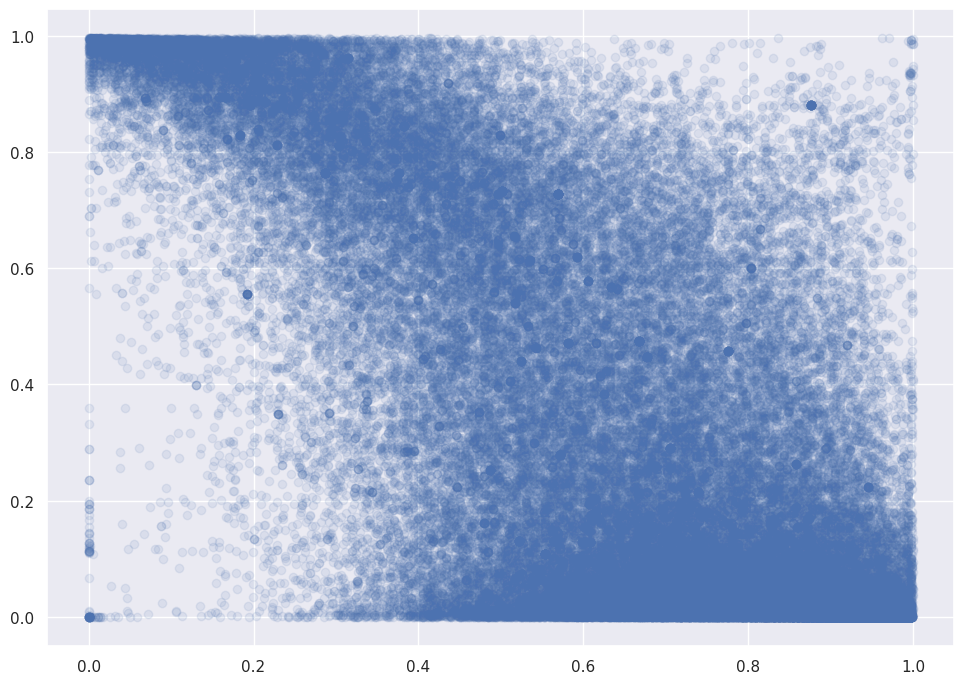

In [ ]:
plt.scatter(x=df["energy"], y=df["acousticness"], alpha=0.1)

1 CLUSTERS


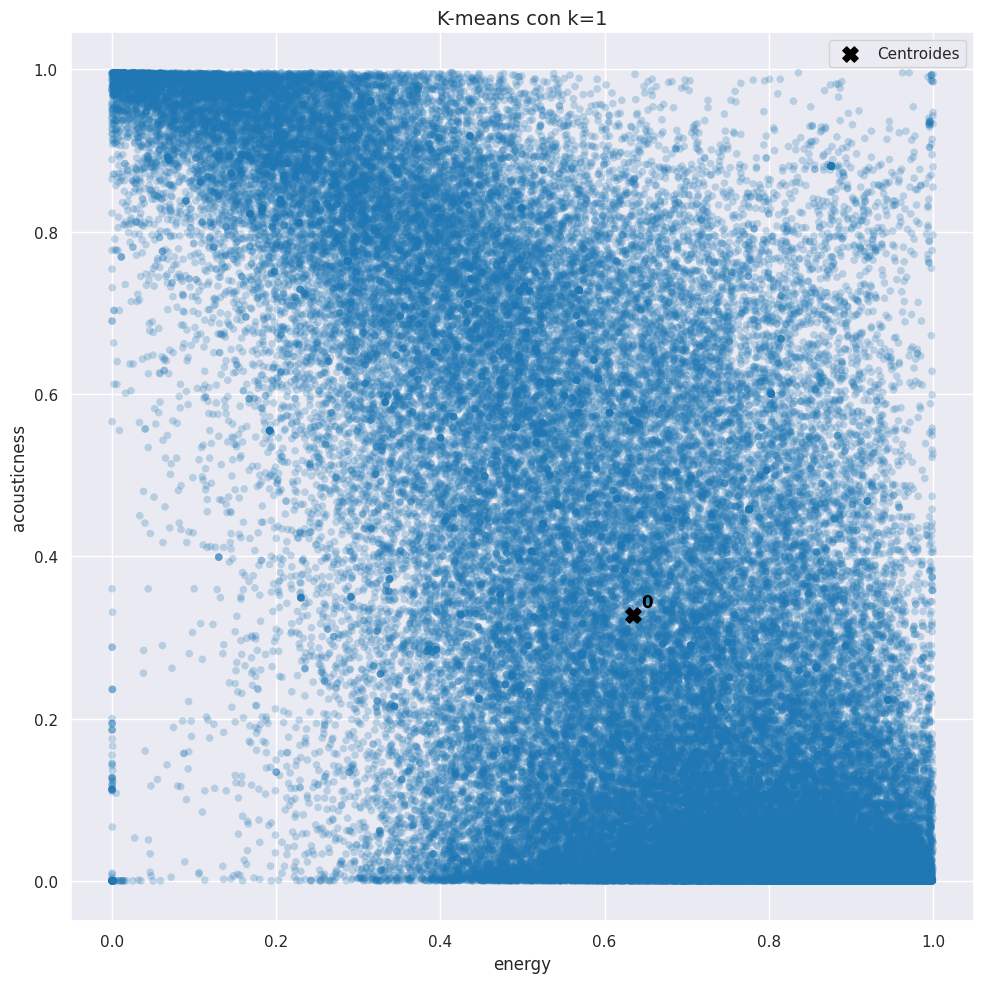

Punto más cercano a cada centroide:
Cluster 0: https://open.spotify.com/track/2fsPrE2NYiHOHPMuWbjvTj


2 CLUSTERS


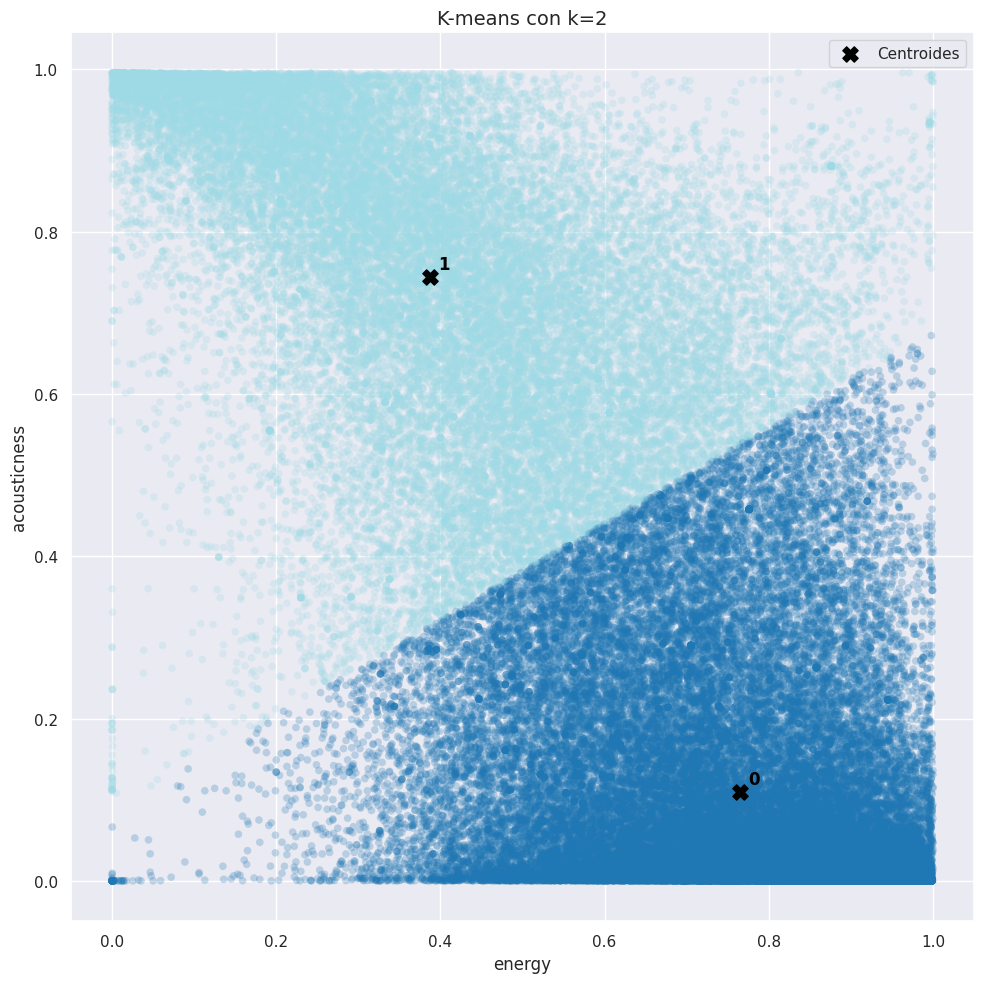

Punto más cercano a cada centroide:
Cluster 0: https://open.spotify.com/track/58dGRQrNmAJeRMFuguUbvD
Cluster 1: https://open.spotify.com/track/1B5Tp2Ml9nLlmTSJx8xVfI


3 CLUSTERS


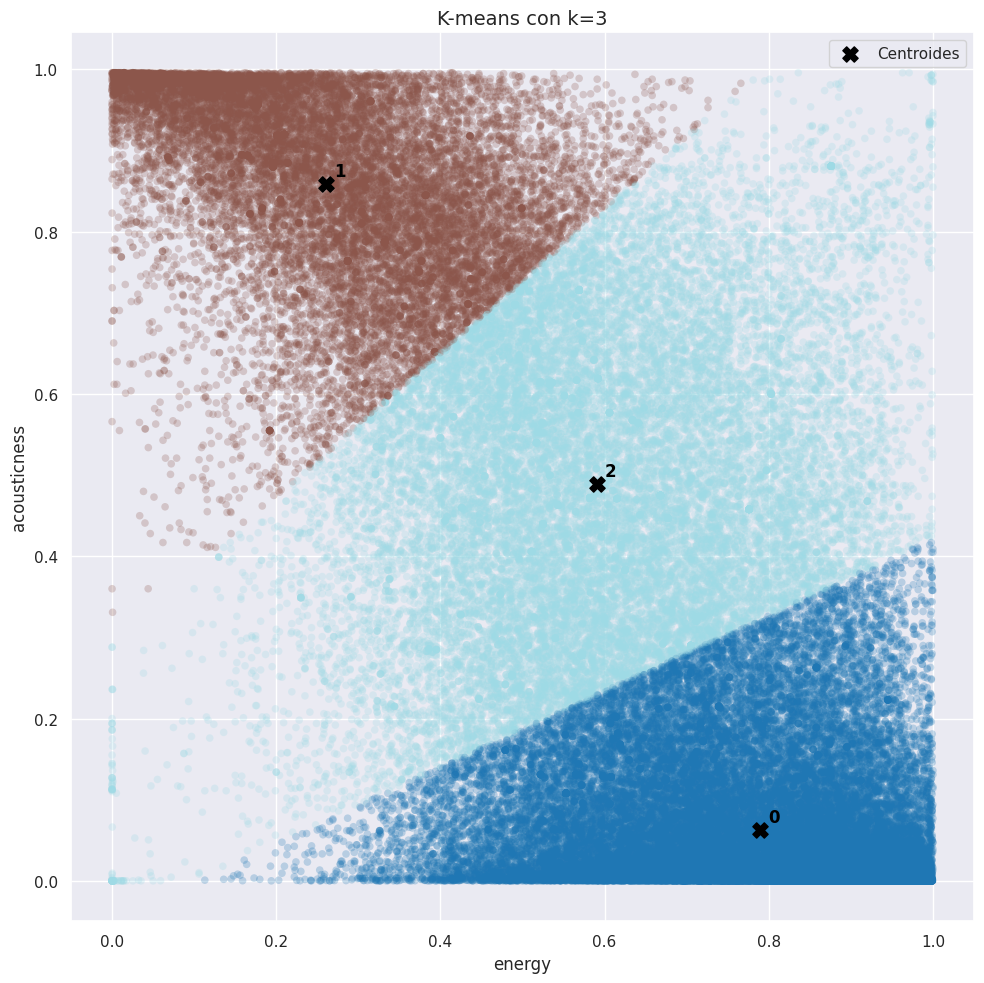

Punto más cercano a cada centroide:
Cluster 0: https://open.spotify.com/track/45C5umkVyhwbYuLNYPtJ1O
Cluster 1: https://open.spotify.com/track/0210gFYpVnijFhx38qw4Zf
Cluster 2: https://open.spotify.com/track/0tikP9agfqFyjJS4NLJHxp


5 CLUSTERS


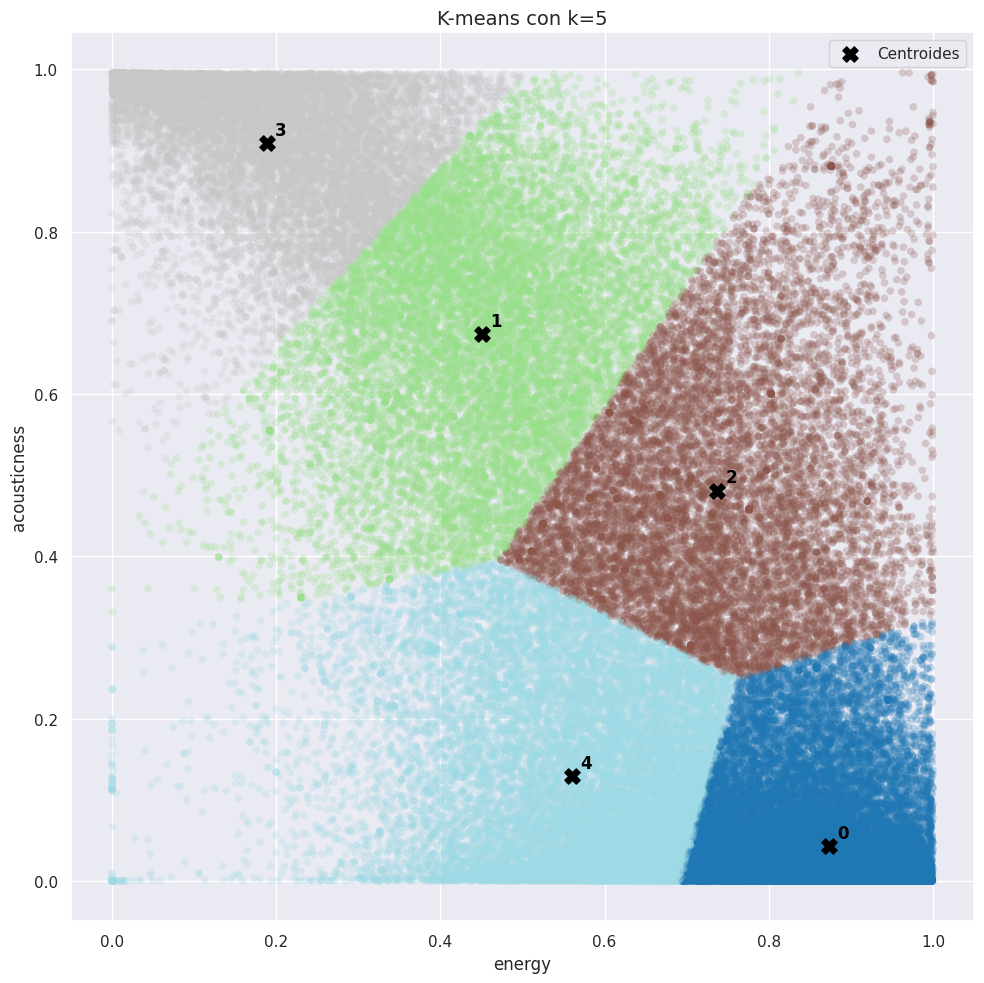

Punto más cercano a cada centroide:
Cluster 0: https://open.spotify.com/track/1zIEjkEd2awwjVTxqPPecY
Cluster 1: https://open.spotify.com/track/5TDmdYEnP5KBeK068PEVNl
Cluster 2: https://open.spotify.com/track/1D6lK8qADoErTTLkY4YBfM
Cluster 3: https://open.spotify.com/track/3Kj2EWpIBnvETsYq4cq0IH
Cluster 4: https://open.spotify.com/track/0apq2ENNMlYg9Os1osfJ3Y


10 CLUSTERS


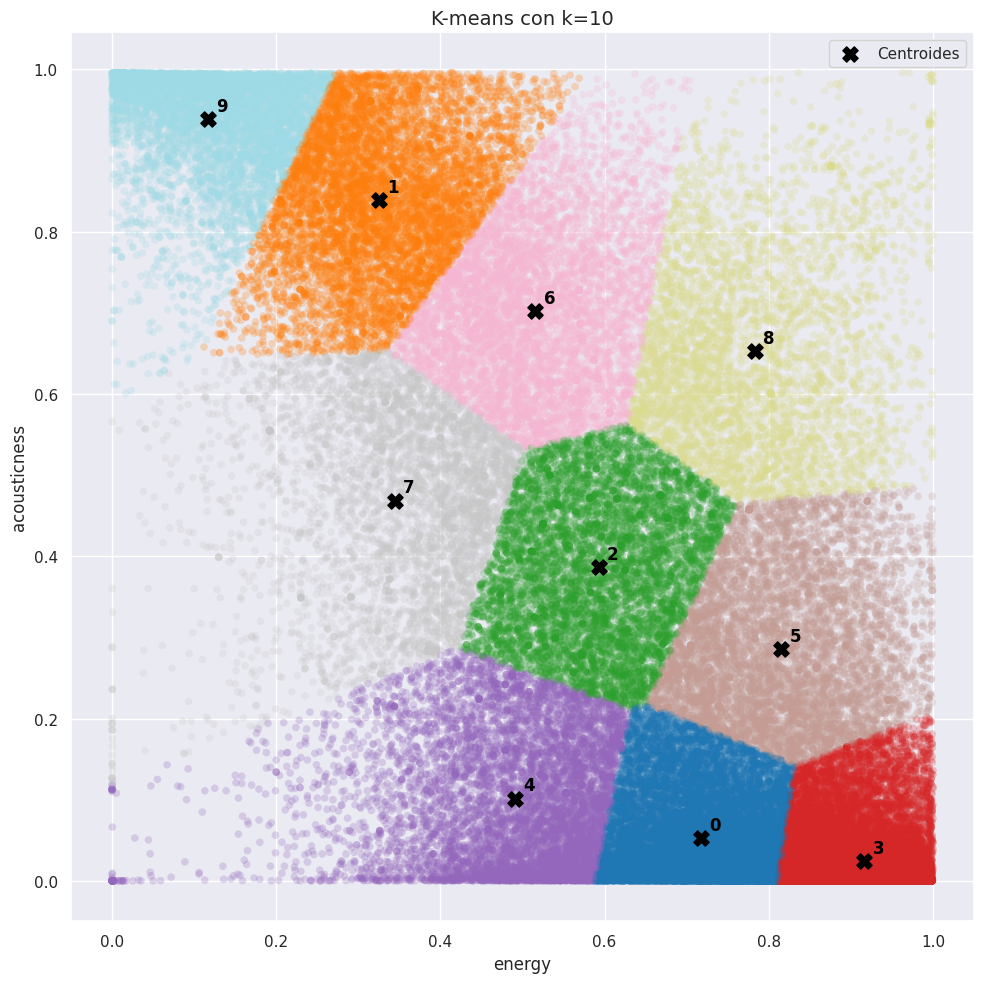

Punto más cercano a cada centroide:
Cluster 0: https://open.spotify.com/track/7tOcPDj3vyopZ404pY6UuP
Cluster 1: https://open.spotify.com/track/3MloP5bPLvnYIQrqY4M6P1
Cluster 2: https://open.spotify.com/track/0M4MO3Ax1xZJIVgXVjV3p2
Cluster 3: https://open.spotify.com/track/2IlivxoEfhgiVyuzNmEjfP
Cluster 4: https://open.spotify.com/track/7dfl9X38RhIvB3oSmmneq3
Cluster 5: https://open.spotify.com/track/38YDsF1EiNfQiS5x6xJsyS
Cluster 6: https://open.spotify.com/track/2IAumRplFr0Ns09kKgt2je
Cluster 7: https://open.spotify.com/track/4qXVjZZ48aShiyCqxhkuJP
Cluster 8: https://open.spotify.com/track/1zWsZqGND3kcUu8WgXVirO
Cluster 9: https://open.spotify.com/track/2Se6vKr55KFWQUwtqRqV08


20 CLUSTERS


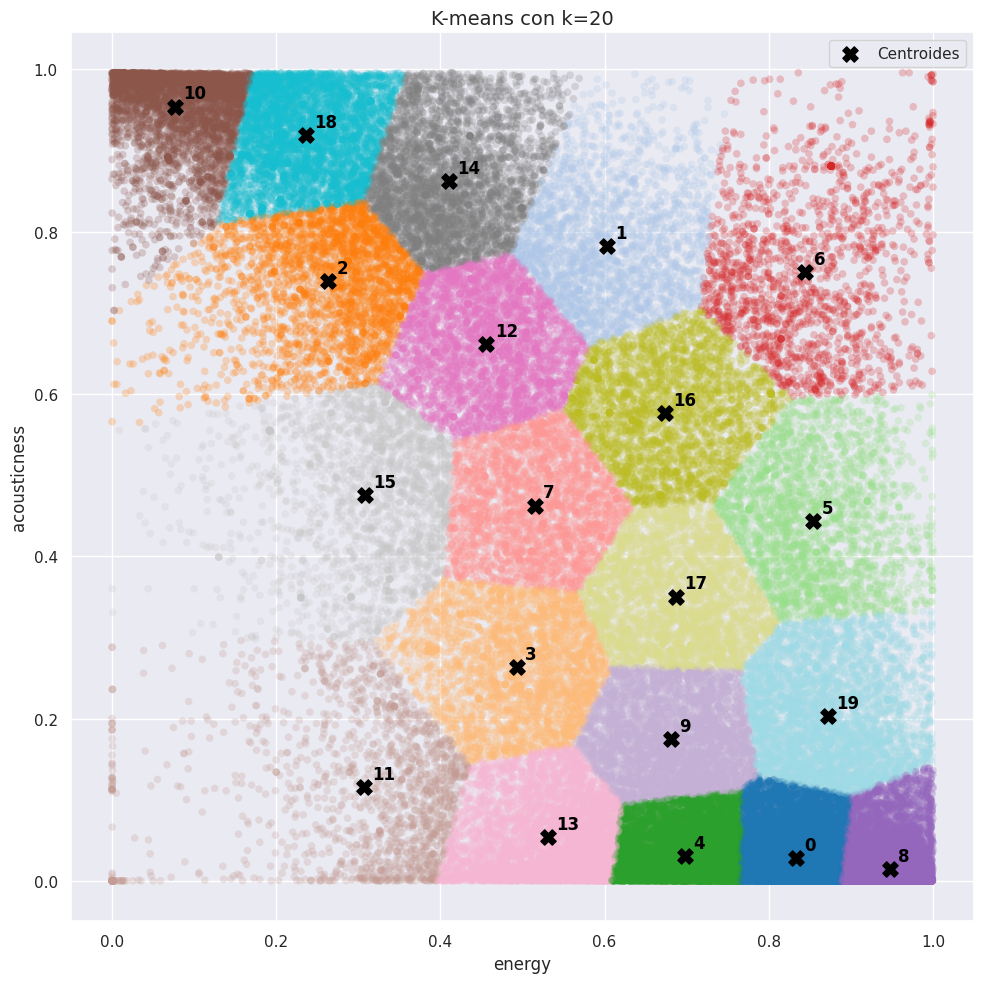

Punto más cercano a cada centroide:
Cluster 0: https://open.spotify.com/track/0oo6NX5bPcqUbX7eJtoslO
Cluster 1: https://open.spotify.com/track/2H87pSpxWMDqFeNtPslCWp
Cluster 2: https://open.spotify.com/track/4VZAiJm5BugPrnlsMzqgUu
Cluster 3: https://open.spotify.com/track/4x3HfjXyiGKU4EZYutNNfI
Cluster 4: https://open.spotify.com/track/46lUgixgC1Q39P0oWwJZLF
Cluster 5: https://open.spotify.com/track/65IjEAkQgHUIicxDS6BevW
Cluster 6: https://open.spotify.com/track/6lZ15n1ekKcGckQQZRd3bC
Cluster 7: https://open.spotify.com/track/49b0lWRHXFe8FKwX3mUQSX
Cluster 8: https://open.spotify.com/track/46cEIa1iQPSQLnPVP2hmVm
Cluster 9: https://open.spotify.com/track/1XSBetDB37QhmsBkfHvaTW
Cluster 10: https://open.spotify.com/track/7LsPFCJwUkyQEAP69AaNYb
Cluster 11: https://open.spotify.com/track/6BpAWwyBHflLoBa6b1KOZq
Cluster 12: https://open.spotify.com/track/2ZRo7axmMPeSVUvDbGkJah
Cluster 13: https://open.spotify.com/track/1wirHkULbAEyUu9G4qGwuR
Cluster 14: https://open.spotify.com/track/2ettInV

In [ ]:
cols=["energy", "acousticness"]
for k in [1, 2, 3, 5, 10, 20]:
  print(f"{k} CLUSTERS")
  plot_kmeans(df, cols, k)
  print()
  print()

# Ejercicio 2: Intuición sobre el clustering de Spotify

Vamos a desarrollar una intuición sobre clustering: qué tipo de clusters aparecen, qué variables son importantes o no, cómo varía la distribución de las variables en cada clúster...

De manera iterativa, variando el número de clústers:
- Crea los clústers con el modelo k-means.
- Observa la distribución de las variables en cada clúster, puedes hacerlo con:
  - gráficos de distribución: stripplot, boxplot, violin, histogram
  - radar plot
- Intenta obtener una intuición de los clusters: escucha canciones de un mismo cluster, o la más cercana al centroide (url de una canción = "https://open.spotify.com/track/"+track_id)

# Ejercicio 3: Número óptimo de clusters

Vamos a intentar definir un número óptimo de clusters para este dataset.

- Antes de comentar ¿Cuántos crees que deberían ser?
- Usa el método del codo para intentar encontrar un número

Tras realizarlo

- Reflexiona ¿qué ha ocurrido?

# Ejercicio 4: Asignación de clúster
Escoge una canción que te encante (y que sea parte del dataset).

- Qué clúster le corresponde?
- Selecciona las 3 canciones con una distancia euclidea más corta a tu canción, te resultan parecidas? te gustan?
- Ahora, selecciona las 3 más alejadas, cómo son?
- Crea una lista de reprodución inspirada en esta canción que contenga:
 - 3 canciones de las 20 más cercanas (al azar)
 - 3 canciones de entre cualquiera del cluster (al azar)
 - la propia canción


Ejemplos de canciones:

In [ ]:
# Drake: God's Plan
track_id = "6DCZcSspjsKoFjzjrWoCdn"
print(f"https://open.spotify.com/track/{track_id}")

https://open.spotify.com/track/6DCZcSspjsKoFjzjrWoCdn


In [ ]:
# Billie Elish: Bad guy
track_id = "2Fxmhks0bxGSBdJ92vM42m"
print(f"https://open.spotify.com/track/{track_id}")

https://open.spotify.com/track/2Fxmhks0bxGSBdJ92vM42m


In [ ]:
# Metronomy: The Look
track_id = "6zfczP87XO2SxWlQtnjFNa"
print(f"https://open.spotify.com/track/{track_id}")

https://open.spotify.com/track/6zfczP87XO2SxWlQtnjFNa


In [ ]:
# Hans Zimmer: Cornfield Chase
track_id = "6pWgRkpqVfxnj3WuIcJ7WP"
print(f"https://open.spotify.com/track/{track_id}")

https://open.spotify.com/track/6pWgRkpqVfxnj3WuIcJ7WP


In [ ]:
# Bad Bunny: Tití me preguntó
track_id = "1IHWl5LamUGEuP4ozKQSXZ"
print(f"https://open.spotify.com/track/{track_id}")

https://open.spotify.com/track/1IHWl5LamUGEuP4ozKQSXZ


In [ ]:
# Karol G: Provenza
track_id = "7dSZ6zGTQx66c2GF91xCrb"
print(f"https://open.spotify.com/track/{track_id}")

https://open.spotify.com/track/7dSZ6zGTQx66c2GF91xCrb


In [ ]:
df[["karol" in artist.lower() for artist in df["artists"]]].sort_values("popularity", ascending=False)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
71947,7dSZ6zGTQx66c2GF91xCrb,KAROL G,PROVENZA,PROVENZA,93,210200,False,0.870,0.516,1,...,1,0.0541,0.6560,0.008230,0.110,0.530,111.005,4,reggae,1
71995,1ga4PztXOIw1yBbdUt2X8v,KAROL G;Maldy,GATÚBELA,GATÚBELA,90,209160,False,0.627,0.858,11,...,0,0.3860,0.2630,0.000000,0.210,0.342,92.523,4,reggae,3
72020,1ri9ZUkBJVFUdgwzCnfcYs,Becky G;KAROL G,MAMIII,MAMIII,85,226088,False,0.843,0.700,4,...,0,0.0803,0.0934,0.000000,0.140,0.899,93.991,4,reggae,8
27763,0bI7K9Becu2dtXK1Q3cZNB,Tiësto;KAROL G,Don't Be Shy,Don't Be Shy,84,140500,True,0.770,0.787,11,...,0,0.0583,0.1980,0.000000,0.262,0.513,119.986,4,edm,8
72069,7FlQk2gJ6TBrHHiidvdR2O,Becky G;KAROL G,ESQUEMAS,MAMIII,81,226093,False,0.836,0.703,4,...,0,0.0657,0.0845,0.000000,0.138,0.902,94.048,4,reggae,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71887,2UzdMpV9R6H1Aex1yXExli,KAROL G;Maluma,Verano en Junio,Créeme,0,214293,False,0.714,0.874,6,...,1,0.0549,0.1280,0.000146,0.105,0.648,96.998,4,reggae,6
71892,1bNsvWmJGd4pdpahQhlK9T,KAROL G,Perreo Tenebroso Vol. 3,Bebesita,0,185053,False,0.714,0.826,7,...,0,0.0385,0.3180,0.000016,0.216,0.742,91.997,4,reggae,6
81899,3cgPLCz2XwX95aNp50RYEE,Antonio Orozco;KAROL G,Carrete con besties,Dicen,0,221992,False,0.710,0.824,10,...,0,0.1470,0.1280,0.000000,0.399,0.890,88.942,4,spanish,6
81905,6R6GLuPhYvJbc7nR1suhp1,Antonio Orozco;KAROL G,Para entrar en calor,Dicen,0,221992,False,0.710,0.824,10,...,0,0.1470,0.1280,0.000000,0.399,0.890,88.942,4,spanish,6


### Asignación de clúster

### Distancias

### Lista de reproducción

# Ejercicio opcional: IA generativa
Usa los títulos de las canciones de tu playlist para:
- generar un prompt que te dé un buen título de playlist
- generar una imagen de carátula para la playlist

# QR Evaluación Javi


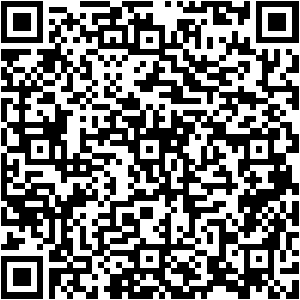

# QR Evaluación Jimena

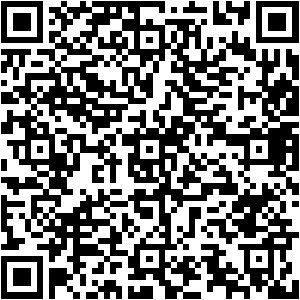